In [ ]:
# ============================================================
# FT MULTITUBULAR FIXED-BED REACTOR SIZING (GHSV METHOD)
# FULL CODE (PROFESSIONAL OUTPUT)
#
# Key features:
# 1) Uses YOUR inlet streams: FT_rec_heated + FT_in  (kmol/h)
# 2) Sizes catalyst volume by GHSV at reactor T,P
# 3) Automatically chooses:
#      - the MINIMUM number of parallel reactors N
#      - and (for that N) the MINIMUM tube length that satisfies:
#           (a) Shell ID Ds <= Ds_max_m
#           (b) L/D within [LD_min, LD_max]  <-- NOW SET TO 3–5
#    This means we fix L/D by INCREASING HEIGHT (tube length) first,
#    and only increase N if required by diameter feasibility.
# 4) Computes ΔP using Ergun equation (per reactor)
# 5) Thermal check (hot-spot indicator):
#      - Q_rxn (MW), Q_cool (MW), ΔT_ad (°C)
#
# Definitions:
# - Reactor diameter D = Ds (shell inner diameter)
# - Reactor height H ≈ Lshell = 1.2*L_tube
# ============================================================

import math

try:
    import pandas as pd
except ImportError:
    pd = None


# =========================
# 1) YOUR FT STREAM DATA (kmol/h)
# =========================
FT_rec_heated = {
    "C1": 268.98,
    "C3": 45.71,
    "C6": 2.00,
    "C11": 0.00,
    "C18": 0.00,
    "CO": 198.07,
    "CO2": 189.32,
    "H2": 17282.51,
    "H2O": 1.15,
}

FT_in = {
    "C1": 27.06,
    "C3": 0.00,
    "C6": 0.73,
    "C11": 0.00,
    "C18": 0.00,
    "CO": 1421.12,
    "CO2": 203.34,
    "H2": 20920.52,
    "H2O": 47.54,
}


# =========================
# 2) MWs (kg/kmol) + Cp data (kJ/kmol.K) from YOUR Cp table
# =========================
MW = {
    "H2": 2.016,
    "CO": 28.01,
    "CO2": 44.01,
    "H2O": 18.015,
    "C1": 16.043,
    "C3": 44.11,
    "C6": 86.1779,
    "C11": 156.31,
    "C18": 254.49,
}

Cp_kJ_kmolK = {
    "C1": 102.244515,
    "C3": 134.5821805,
    "C6": 259.1919756,
    "C11": 477.5820572,
    "C18": 752.7197428,
    "CO": 30.7507513,
    "CO2": 48.40242581,
    "H2": 29.37548769,
    "H2O": 36.81863916,
}


# =========================
# 3) REACTION EXTENTS + HEATS (YOUR FT “moles of reaction” table)
# =========================
extents_kmol_h = {
    "C1": 260.5129105,
    "C3": 57.61741815,
    "C6": 37.82304527,
    "C11": 42.61473710,
    "C18": 6.55611340,
}

dH_kJ_per_kmol = {
    "C1": -206166,
    "C3": -498588,
    "C6": -954876,
    "C11": -1714556,
    "C18": -2777928,
}


# =========================
# 4) DESIGN INPUTS (EDIT THESE)
# =========================
T_C = 220.0
P_bar = 25.0
Z = 1.0

GHSV_per_h = 2000.0

Ds_max_m = 4.0
N_max_search = 12

# ----- UPDATED HERE: L/D TARGET RANGE = 3–5 -----
LD_min = 3.0
LD_max = 5.0

# Tube length search range (increase max if needed to meet L/D >= 3)
L_tube_min = 4.0
L_tube_max = 16.0   # increased from 12 to help meet L/D >= 3
L_tube_step = 0.5

porosity = 0.64
dp_m = 0.66e-3
mu_Pa_s = 2.0e-5

Di_m = 34.8e-3
Do_m = 38.0e-3

Kt = 0.215
n_exp = 2.207
clearance_m = 0.097


# =========================
# 5) HELPER FUNCTIONS
# =========================
def kmolh_to_kmols(F_kmol_h: float) -> float:
    return F_kmol_h / 3600.0

def bar_to_Pa(P_bar: float) -> float:
    return P_bar * 1e5

def ideal_vol_flow_m3_s(Ftot_kmol_h: float, T_K: float, P_bar: float, Z: float) -> float:
    n_kmol_s = kmolh_to_kmols(Ftot_kmol_h)
    R = 8.314e3
    P = bar_to_Pa(P_bar)
    return Z * n_kmol_s * R * T_K / P

def mixture_MW_kg_kmol(flow_kmol_h: dict) -> float:
    Ftot = sum(flow_kmol_h.values())
    if Ftot <= 0:
        return 0.0
    return sum((F / Ftot) * MW.get(sp, 0.0) for sp, F in flow_kmol_h.items())

def mixture_Cp_kJ_kmolK(flow_kmol_h: dict) -> float:
    Ftot = sum(flow_kmol_h.values())
    if Ftot <= 0:
        return 0.0
    Cp_mix = 0.0
    missing = []
    for sp, F in flow_kmol_h.items():
        if sp not in Cp_kJ_kmolK:
            missing.append(sp)
            continue
        Cp_mix += (F / Ftot) * Cp_kJ_kmolK[sp]
    if missing:
        raise ValueError(f"Missing Cp for species: {missing}. Add them to Cp_kJ_kmolK.")
    return Cp_mix

def gas_density_kg_m3(P_bar: float, T_K: float, MWmix_kg_kmol: float, Z: float) -> float:
    P = bar_to_Pa(P_bar)
    R = 8.314e3
    return P * MWmix_kg_kmol / (Z * R * T_K)

def tube_internal_volume(Di: float, L: float) -> float:
    return (math.pi * Di**2 / 4.0) * L

def number_of_tubes(Vreactor_m3: float, Di: float, L: float) -> int:
    Vtube = tube_internal_volume(Di, L)
    return max(1, int(round(Vreactor_m3 / Vtube)))

def bundle_diameter(Nt: int, Do: float, Kt: float, n_exp: float) -> float:
    return Do * ((Nt / Kt) ** (1.0 / n_exp))

def shell_ID(Db: float, clearance: float) -> float:
    return Db + clearance

def shell_length(L_tube: float) -> float:
    return L_tube * 1.2

def total_tube_flow_area(Nt: int, Di: float) -> float:
    return Nt * (math.pi * Di**2 / 4.0)

def shell_flow_area(Dshell: float) -> float:
    return math.pi * Dshell**2 / 4.0

def ergun_deltaP_bar(eps: float, dp: float, mu: float, rho: float, vs: float, L: float) -> float:
    term1 = 150.0 * ((1-eps)**2) / (eps**3) * (mu * vs) / (dp**2)
    term2 = 1.75 * (1-eps) / (eps**3) * (rho * vs**2) / dp
    dP_Pa = (term1 + term2) * L
    return dP_Pa / 1e5

def frange(start, stop, step):
    n = int(round((stop - start) / step))
    return [start + i * step for i in range(n + 1)]

def penalty(value, low, high):
    if value < low:
        return (low - value) ** 2
    if value > high:
        return (value - high) ** 2
    return 0.0

def print_table(title: str, rows):
    print(f"\n>>> {title}")
    maxk = max(len(r[0]) for r in rows)
    for k, v in rows:
        print(f"{k:<{maxk}} : {v}")

def kJph_to_MW(Q_kJ_h: float) -> float:
    return Q_kJ_h / 3.6e6


# =========================
# 6) TOTAL BASIS (SECTION)
# =========================
species = sorted(set(FT_rec_heated) | set(FT_in))
FT_total_in = {s: FT_rec_heated.get(s, 0.0) + FT_in.get(s, 0.0) for s in species}

Ftot_kmol_h_total = sum(FT_total_in.values())
T_K = T_C + 273.15

Vdot_m3_s_total = ideal_vol_flow_m3_s(Ftot_kmol_h_total, T_K, P_bar, Z)
Vdot_m3_h_total = Vdot_m3_s_total * 3600.0

MWmix_total = mixture_MW_kg_kmol(FT_total_in)
Cp_mix_total = mixture_Cp_kJ_kmolK(FT_total_in)
rho_total = gas_density_kg_m3(P_bar, T_K, MWmix_total, Z)

# Thermal: total heat of reaction (section basis)
Q_rxn_kJ_h_total = sum(extents_kmol_h[p] * dH_kJ_per_kmol[p] for p in extents_kmol_h)  # negative exo
Q_cool_kJ_h_total = -Q_rxn_kJ_h_total
dT_ad_C_total = (Q_cool_kJ_h_total) / (Ftot_kmol_h_total * Cp_mix_total)

Q_rxn_MW_total = kJph_to_MW(Q_rxn_kJ_h_total)
Q_cool_MW_total = kJph_to_MW(Q_cool_kJ_h_total)


# =========================
# 7) DESIGN SEARCH FOR A GIVEN N (INCREASE HEIGHT FIRST)
# =========================
def design_for_N_with_L_search(N_parallel: int):
    Vdot_each_m3_h = Vdot_m3_h_total / N_parallel
    Vdot_each_m3_s = Vdot_each_m3_h / 3600.0

    Vcat = Vdot_each_m3_h / GHSV_per_h
    Vreact = Vcat / (1.0 - porosity)

    best_compromise = None

    for L_tube in frange(L_tube_min, L_tube_max, L_tube_step):
        Nt = number_of_tubes(Vreact, Di_m, L_tube)
        Db = bundle_diameter(Nt, Do_m, Kt, n_exp)
        Ds = shell_ID(Db, clearance_m)

        Lshell = shell_length(L_tube)
        H = Lshell
        LD = Lshell / Ds if Ds > 0 else float("inf")

        At = total_tube_flow_area(Nt, Di_m)
        As = shell_flow_area(Ds)

        vs = Vdot_each_m3_s / At
        dP = ergun_deltaP_bar(porosity, dp_m, mu_Pa_s, rho_total, vs, L_tube)

        ok_D = (Ds <= Ds_max_m)
        ok_LD = (LD_min <= LD <= LD_max)

        cand = {
            "N": N_parallel,
            "L_tube_m": L_tube,
            "Vdot_each_m3_h": Vdot_each_m3_h,
            "Vcat_m3": Vcat,
            "Vreact_m3": Vreact,
            "Nt": Nt,
            "Db_m": Db,
            "Ds_m": Ds,
            "Lshell_m": Lshell,
            "H_m": H,
            "L_over_D": LD,
            "At_m2": At,
            "As_m2": As,
            "As_gt_At": (As > At),
            "vs_m_s": vs,
            "dP_bar": dP,
        }

        if ok_D and ok_LD:
            cand["status"] = "OK"
            cand["penalty"] = 0.0
            return cand

        pen = penalty(Ds, 0.0, Ds_max_m) + penalty(LD, LD_min, LD_max)
        cand["status"] = "COMPROMISE"
        cand["penalty"] = pen

        if best_compromise is None or pen < best_compromise["penalty"]:
            best_compromise = cand

    return best_compromise


# =========================
# 8) AUTO-SELECT MINIMUM N
# =========================
solutions = [design_for_N_with_L_search(N) for N in range(1, N_max_search + 1)]
ok_solutions = [s for s in solutions if s["status"] == "OK"]

if ok_solutions:
    best = ok_solutions[0]
    auto_msg = (
        f"Auto-selected minimum N = {best['N']} and tube length = {best['L_tube_m']:.2f} m "
        f"to satisfy Ds <= {Ds_max_m:.2f} m and {LD_min:.0f}<=L/D<={LD_max:.0f}."
    )
else:
    best = min(solutions, key=lambda s: s["penalty"])
    auto_msg = (
        f"No solution satisfied BOTH constraints within N<= {N_max_search} and tube length "
        f"{L_tube_min:.1f}–{L_tube_max:.1f} m. Showing best compromise: "
        f"N={best['N']}, L_tube={best['L_tube_m']:.2f} m."
    )

N_sel = best["N"]

# Per-reactor thermal
Q_rxn_MW_each = Q_rxn_MW_total / N_sel
Q_cool_MW_each = Q_cool_MW_total / N_sel


# =========================
# 9) PRINT RESULTS
# =========================
def main_print():
    print("\n================ FT REACTOR DESIGN SUMMARY ================\n")
    print(auto_msg)

    rows_basis = [
        ("Operating temperature (°C)", f"{T_C:.1f}"),
        ("Operating pressure (bar)", f"{P_bar:.2f}"),
        ("Total inlet flow (kmol/h)", f"{Ftot_kmol_h_total:,.2f}"),
        ("Total volumetric flow @T,P (m³/h)", f"{Vdot_m3_h_total:,.2f}"),
        ("GHSV (h⁻¹)", f"{GHSV_per_h:,.0f}"),
        ("Diameter limit Ds_max (m)", f"{Ds_max_m:.2f}"),
        ("L/D target range", f"{LD_min:.0f} to {LD_max:.0f}"),
        ("Tube length search (m)", f"{L_tube_min:.1f} to {L_tube_max:.1f} (step {L_tube_step:.1f})"),
        ("Chosen N (parallel reactors)", f"{N_sel}"),
        ("Chosen tube length L_tube (m)", f"{best['L_tube_m']:.2f}"),
    ]
    print_table("Design Basis", rows_basis)

    rows_geom = [
        ("Flow per reactor (m³/h)", f"{best['Vdot_each_m3_h']:,.2f}"),
        ("Catalyst volume per reactor Vcat (m³)", f"{best['Vcat_m3']:,.2f}"),
        ("Reactor volume per reactor Vreactor (m³)", f"{best['Vreact_m3']:,.2f}"),
        ("Tubes per reactor Nt (-)", f"{best['Nt']:,d}"),
        ("Bundle diameter Db (m)", f"{best['Db_m']:.2f}"),
        ("Reactor diameter D (m) = Shell ID Ds", f"{best['Ds_m']:.2f}"),
        ("Shell length L (m)", f"{best['Lshell_m']:.2f}"),
        ("Reactor height H (m)", f"{best['H_m']:.2f}"),
        ("L/D (-)", f"{best['L_over_D']:.2f}"),
        ("L/D within range?", "YES" if (LD_min <= best["L_over_D"] <= LD_max) else "NO"),
    ]
    print_table("Per-Reactor Geometry", rows_geom)

    Nt_total = best["Nt"] * N_sel
    rows_tot = [
        ("Total tubes in FT section (-)", f"{Nt_total:,d}"),
        ("Total catalyst volume (m³)", f"{best['Vcat_m3'] * N_sel:,.2f}"),
        ("Total reactor volume (m³)", f"{best['Vreact_m3'] * N_sel:,.2f}"),
    ]
    print_table("Totals (All Reactors)", rows_tot)

    rows_hyd = [
        ("Shell flow area As (m²)", f"{best['As_m2']:,.2f}"),
        ("Total tube flow area At (m²)", f"{best['At_m2']:,.2f}"),
        ("Check As > At ?", "YES" if best["As_gt_At"] else "NO"),
        ("MW_mix (kg/kmol) (approx)", f"{MWmix_total:.2f}"),
        ("Cp_mix (kJ/kmol·K)", f"{Cp_mix_total:.2f}"),
        ("Gas density rho (kg/m³) (approx)", f"{rho_total:.3f}"),
        ("Superficial velocity vs (m/s)", f"{best['vs_m_s']:.3f}"),
        ("Estimated ΔP per reactor (bar)", f"{best['dP_bar']:.3f}"),
    ]
    print_table("Hydraulics (Per Reactor)", rows_hyd)

    rows_therm_total = [
        ("Q_rxn total (MW) (negative = exo)", f"{Q_rxn_MW_total:.3f}"),
        ("Q_cool required total (MW)", f"{Q_cool_MW_total:.3f}"),
        ("Adiabatic ΔT_total (°C) (hot-spot indicator)", f"{dT_ad_C_total:.1f}"),
    ]
    print_table("Thermal Check (Total FT Section)", rows_therm_total)

    rows_therm_each = [
        ("Q_rxn per reactor (MW)", f"{Q_rxn_MW_each:.3f}"),
        ("Q_cool per reactor (MW)", f"{Q_cool_MW_each:.3f}"),
        ("Adiabatic ΔT per reactor (°C)", f"{dT_ad_C_total:.1f}"),
    ]
    print_table("Thermal Check (Per Reactor)", rows_therm_each)

    if pd is not None:
        df_scan = pd.DataFrame([{
            "N": s["N"],
            "L_tube (m)": s["L_tube_m"],
            "Ds (m)": s["Ds_m"],
            "L/D": s["L_over_D"],
            "Status": s["status"],
            "Nt/reactor": s["Nt"],
            "ΔP (bar)": s["dP_bar"],
        } for s in solutions])
        print("\n>>> N Sensitivity (best tube length found for each N)")
        print(df_scan.round(4).to_string(index=False))

    print("\n===========================================================\n")


if __name__ == "__main__":
    main_print()



================ FT REACTOR DESIGN SUMMARY ================

Auto-selected minimum N = 2 and tube length = 9.50 m to satisfy Ds <= 4.00 m and 3<=L/D<=5.

>>> Design Basis
Operating temperature (°C)        : 220.0
Operating pressure (bar)          : 25.00
Total inlet flow (kmol/h)         : 40,608.05
Total volumetric flow @T,P (m³/h) : 66,598.00
GHSV (h⁻¹)                        : 2,000
Diameter limit Ds_max (m)         : 4.00
L/D target range                  : 3 to 5
Tube length search (m)            : 4.0 to 16.0 (step 0.5)
Chosen N (parallel reactors)      : 2
Chosen tube length L_tube (m)     : 9.50

>>> Per-Reactor Geometry
Flow per reactor (m³/h)                  : 33,299.00
Catalyst volume per reactor Vcat (m³)    : 16.65
Reactor volume per reactor Vreactor (m³) : 46.25
Tubes per reactor Nt (-)                 : 5,118
Bundle diameter Db (m)                   : 3.65
Reactor diameter D (m) = Shell ID Ds     : 3.75
Shell length L (m)                       : 11.40
Reactor height H 

>>> Training/Running Evolutionary Optimization...

   ML OPTIMAL DESIGN FOUND
Optimal N (Reactors) : 4
Optimal Tube Length  : 7.62 m
Resulting Diameter   : 3.05 m
Resulting L/D        : 3.00
Pressure Drop        : 1.824 bar
Total Reactor Vol    : 92.50 m3
----------------------------------------


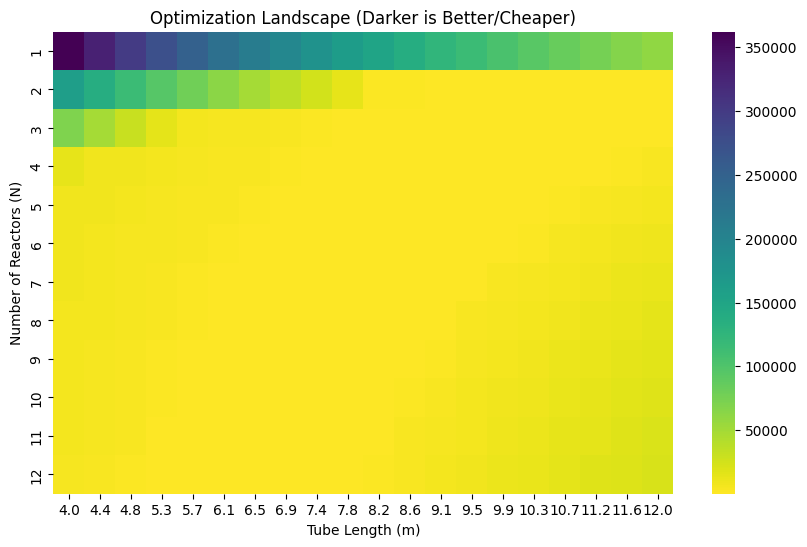

In [ ]:
# ============================================================
# ML OPTIMIZATION: GENETIC ALGORITHM (DIFFERENTIAL EVOLUTION)
# ============================================================
import numpy as np
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. WRAPPER FUNCTION (Re-creates your physics logic for a single point) ---
def evaluate_reactor_physics(N_float, L_tube):
    """
    Calculates reactor performance for a specific N and L.
    Returns a dictionary of results.
    """
    # Force N to be an integer (since we can't have 2.5 reactors)
    N = int(round(N_float))
    if N < 1: N = 1

    # 1. Flow per reactor
    Vdot_each_m3_h = Vdot_m3_h_total / N
    Vdot_each_m3_s = Vdot_each_m3_h / 3600.0

    # 2. Catalyst & Reactor Volume
    Vcat = Vdot_each_m3_h / GHSV_per_h
    Vreact = Vcat / (1.0 - porosity)

    # 3. Geometric calculations
    Nt = number_of_tubes(Vreact, Di_m, L_tube)
    Db = bundle_diameter(Nt, Do_m, Kt, n_exp)
    Ds = shell_ID(Db, clearance_m)
    Lshell = shell_length(L_tube)
    LD = Lshell / Ds if Ds > 0 else 999.0

    # 4. Hydraulics (Pressure Drop)
    At = total_tube_flow_area(Nt, Di_m)
    vs = Vdot_each_m3_s / At
    dP = ergun_deltaP_bar(porosity, dp_m, mu_Pa_s, rho_total, vs, L_tube)

    return {
        "N": N, "L_tube": L_tube, "Ds": Ds, "LD": LD, "Nt": Nt,
        "dP": dP, "V_reactor_total": Vreact * N, "Cost_CapEx_Proxy": Vreact * N * 1.5 + N * 5.0 # Simple economic model
    }

# --- 2. THE OBJECTIVE FUNCTION (The "Loss" Function) ---
def cost_function(x):
    """
    The AI minimizes this function.
    x[0] = N (Number of reactors)
    x[1] = L (Tube length)
    """
    N_curr, L_curr = x

    # Run Physics
    res = evaluate_reactor_physics(N_curr, L_curr)

    # --- PENALTIES (Soft Constraints) ---
    penalty = 0.0

    # Constraint 1: Diameter Max (Hard limit 4.0m)
    if res['Ds'] > Ds_max_m:
        penalty += (res['Ds'] - Ds_max_m) * 100000  # Huge penalty

    # Constraint 2: L/D Ratio (Target 2.0 - 5.0)
    if res['LD'] < LD_min:
        penalty += (LD_min - res['LD']) * 5000
    elif res['LD'] > LD_max:
        penalty += (res['LD'] - LD_max) * 5000

    # --- ECONOMIC OBJECTIVES ---
    # We want to minimize: Volume (CapEx) + Pressure Drop (OpEx)
    # Weights (w): Adjust these to prioritize OpEx vs CapEx
    w_capex = 1.0   # Weight for Reactor Size
    w_opex = 50.0   # Weight for Pressure Drop (Power is expensive!)
    w_count = 20.0  # Penalty for having too many reactors (Complexity)

    # Normalized cost components
    cost_capex = res['V_reactor_total'] * w_capex
    cost_opex = res['dP'] * w_opex
    cost_n = res['N'] * w_count

    total_cost = cost_capex + cost_opex + cost_n + penalty
    return total_cost

# --- 3. RUNNING THE OPTIMIZATION (Differential Evolution) ---
print(">>> Training/Running Evolutionary Optimization...")

# Bounds: N (1 to 12), L (4m to 14m)
bounds = [(1, 12.99), (4.0, 14.0)]

# Run Scipy's Differential Evolution (Genetic Algorithm)
result = differential_evolution(
    cost_function,
    bounds,
    strategy='best1bin',
    maxiter=50,
    popsize=15,
    tol=0.01,
    mutation=(0.5, 1),
    recombination=0.7
)

# --- 4. OUTPUT RESULTS ---
best_N = int(round(result.x[0]))
best_L = result.x[1]
final_design = evaluate_reactor_physics(best_N, best_L)

print("\n" + "="*40)
print(f"   ML OPTIMAL DESIGN FOUND")
print("="*40)
print(f"Optimal N (Reactors) : {final_design['N']}")
print(f"Optimal Tube Length  : {final_design['L_tube']:.2f} m")
print(f"Resulting Diameter   : {final_design['Ds']:.2f} m")
print(f"Resulting L/D        : {final_design['LD']:.2f}")
print(f"Pressure Drop        : {final_design['dP']:.3f} bar")
print(f"Total Reactor Vol    : {final_design['V_reactor_total']:.2f} m3")
print("-" * 40)

# --- 5. VISUALIZATION (Decision Surface) ---
# Create a heatmap to show the "Cost Landscape"
N_range = range(1, 13)
L_range = np.linspace(4, 12, 20)
cost_grid = np.zeros((len(N_range), len(L_range)))

for i, n_val in enumerate(N_range):
    for j, l_val in enumerate(L_range):
        cost_grid[i, j] = cost_function([n_val, l_val])

plt.figure(figsize=(10, 6))
sns.heatmap(cost_grid, xticklabels=np.round(L_range, 1), yticklabels=N_range, cmap='viridis_r')
plt.title("Optimization Landscape (Darker is Better/Cheaper)")
plt.xlabel("Tube Length (m)")
plt.ylabel("Number of Reactors (N)")
plt.show()